First 5 Rows:
   transaction_id  amount_usd merchant_category   card_type  \
0               1       42.86       Restaurants        Visa   
1               2        4.75     Online Retail  Mastercard   
2               3       77.18         Groceries  Mastercard   
3               4        1.69         Streaming        Visa   
4               5      261.68            Travel        Visa   

         auth_method channel    device_type  is_foreign_transaction  \
0                OTP  Online  Android Phone                   False   
1          3D Secure  Online  Android Phone                   False   
2          3D Secure  Online            Mac                   False   
3  No Authentication     POS  Android Phone                   False   
4          3D Secure  In-App         iPhone                   False   

   hours_since_last_txn  txn_count_last_24h  ...  ip_country_mismatch  \
0                 13.54                   2  ...                False   
1                  0.71           

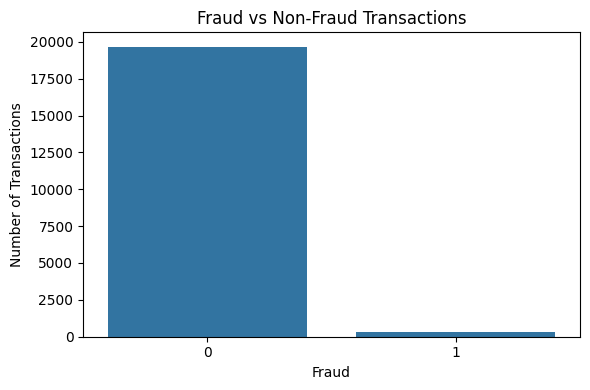

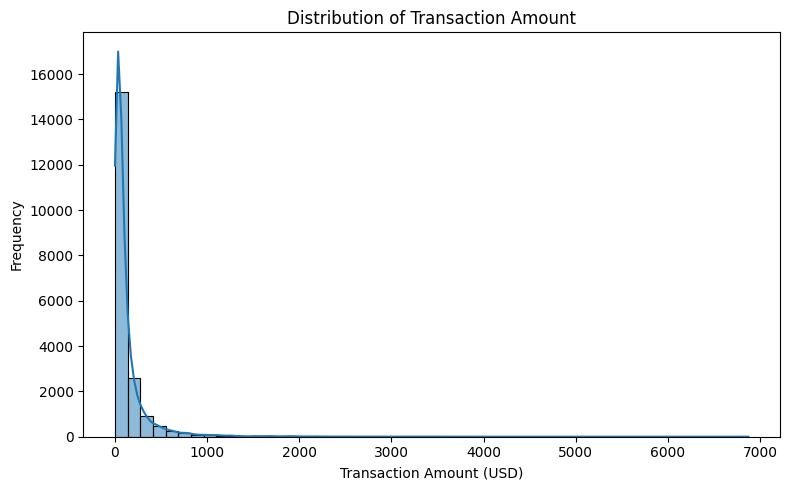

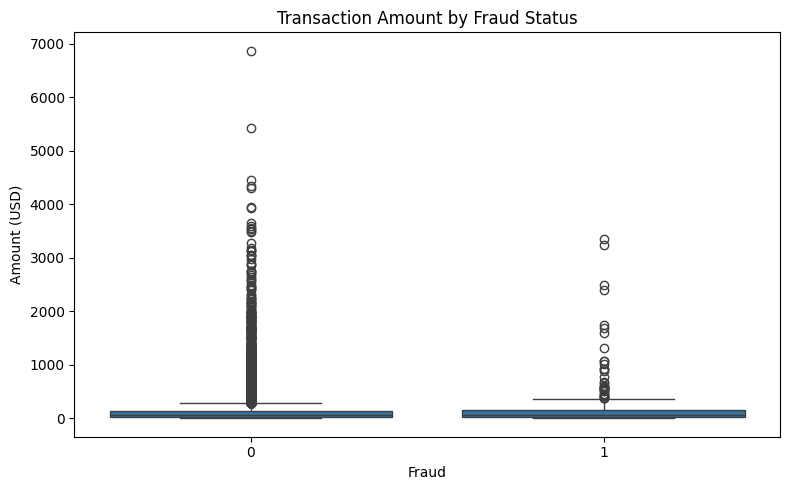

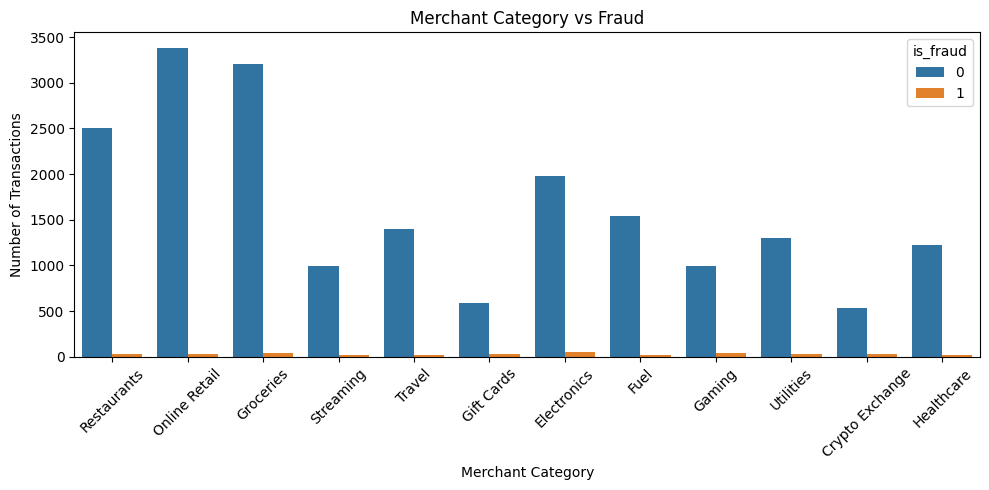

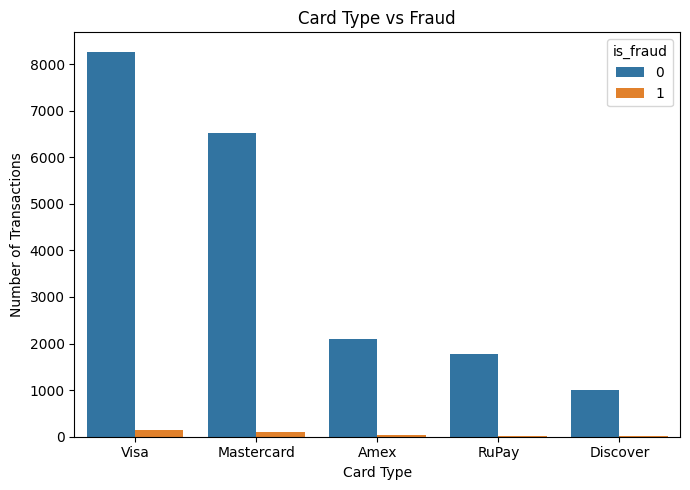

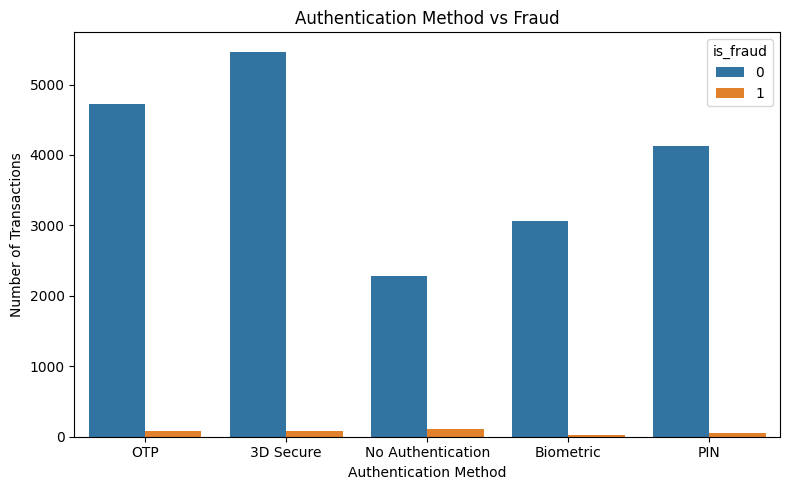

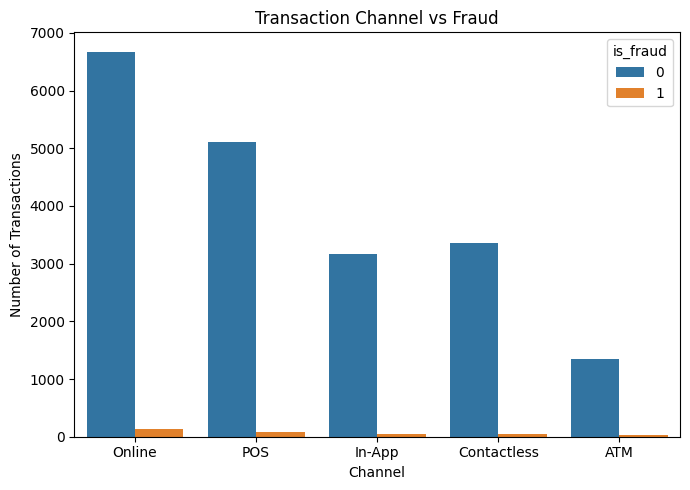

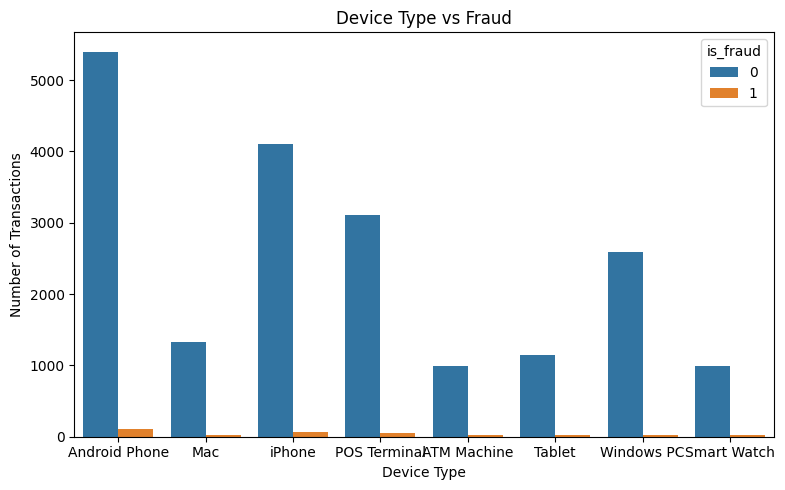

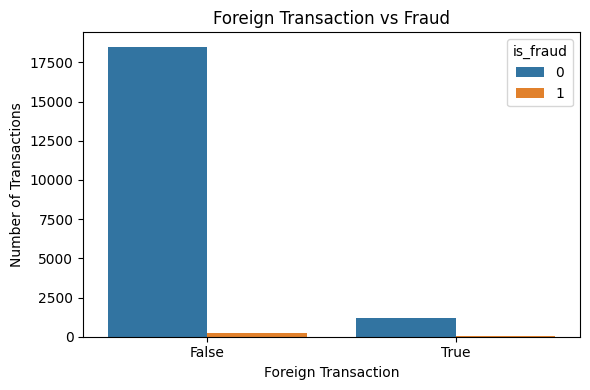

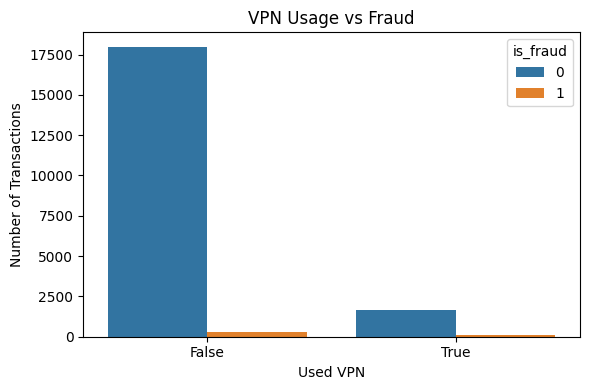

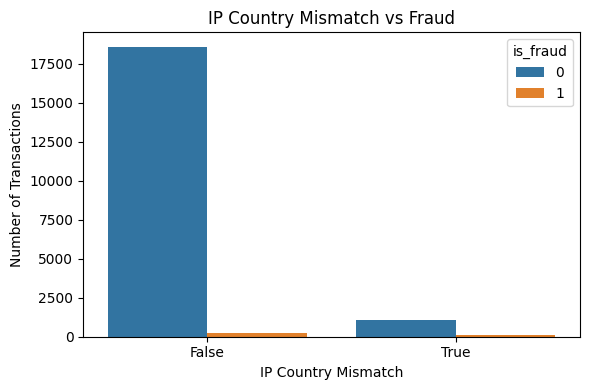

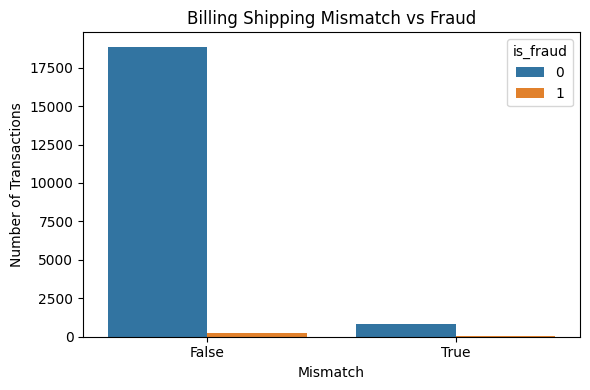

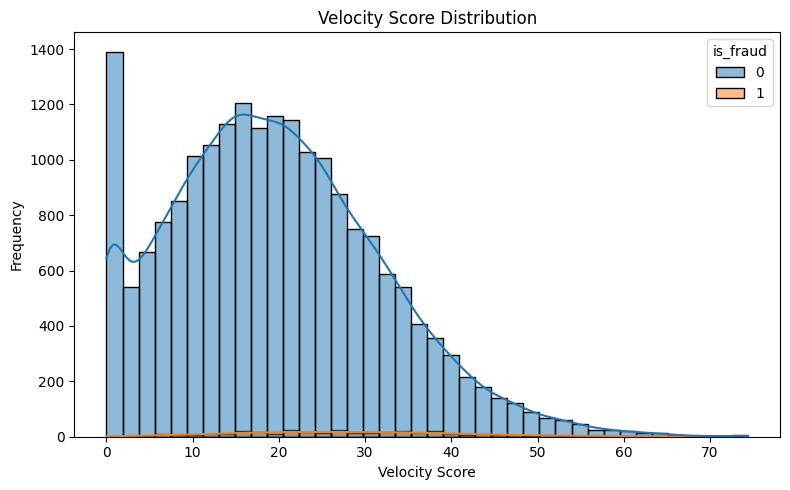

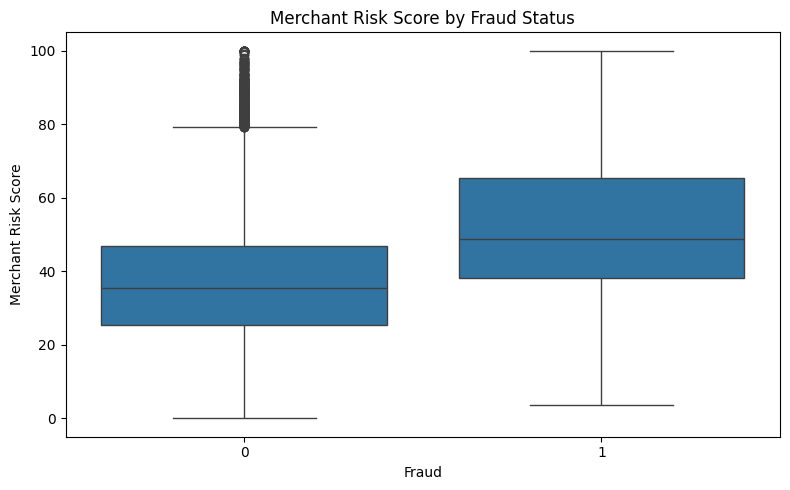

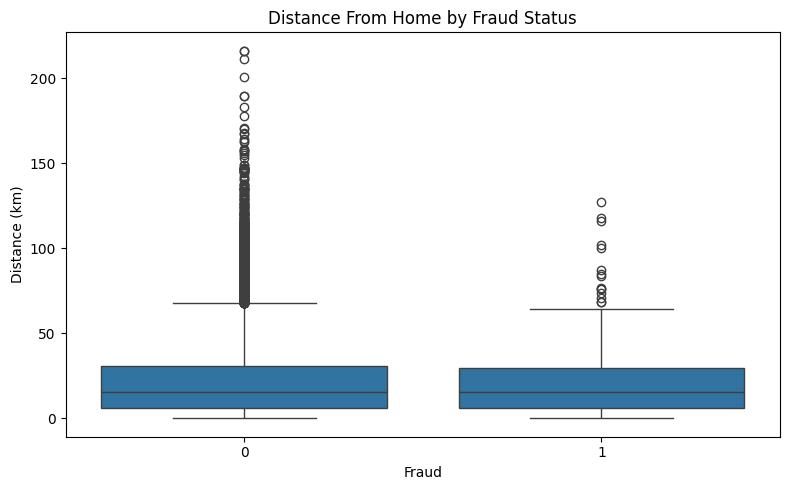

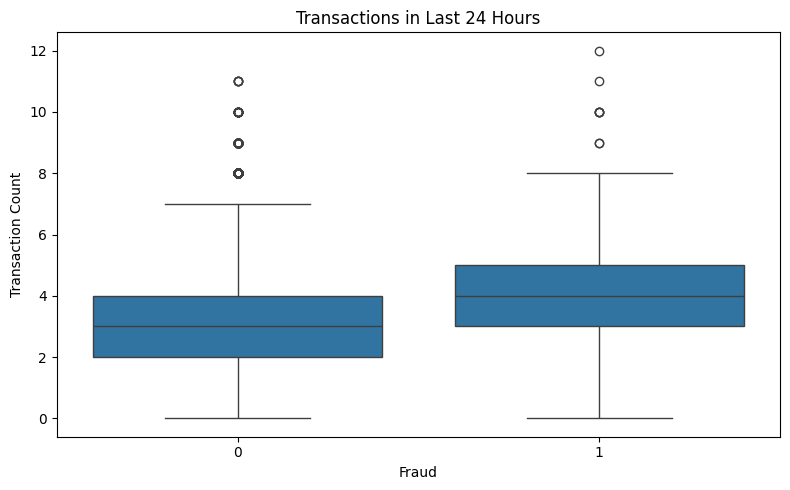

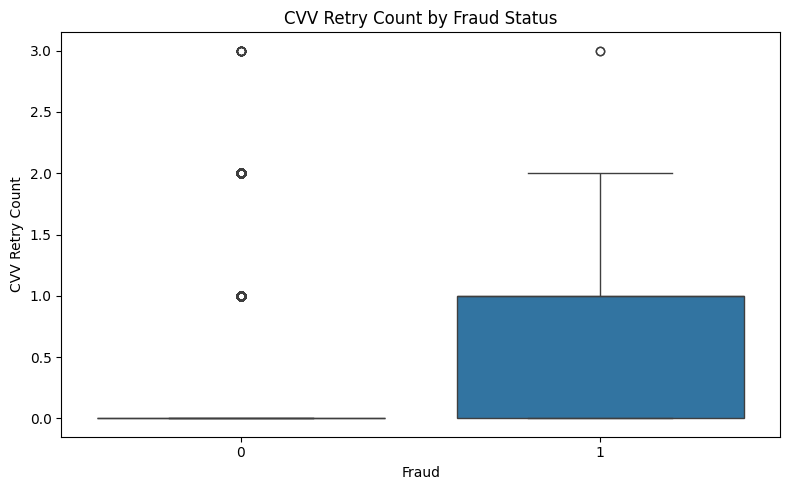

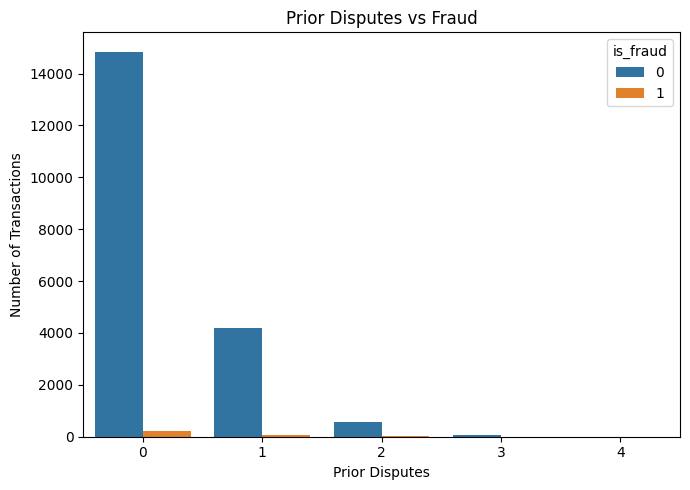

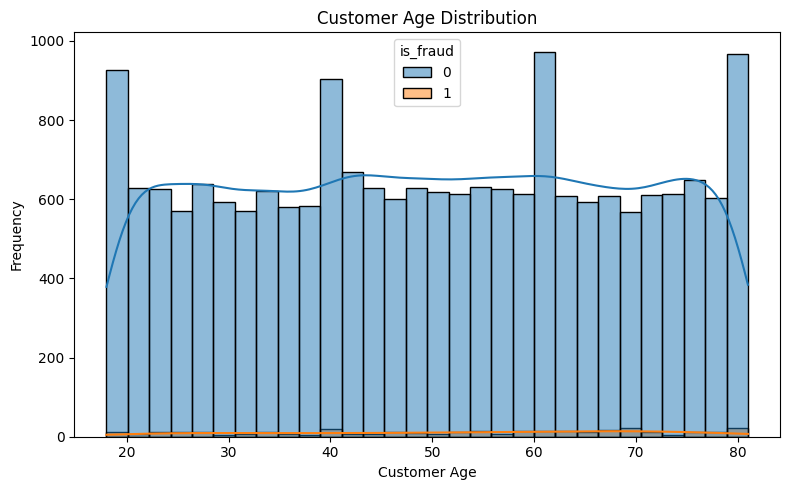

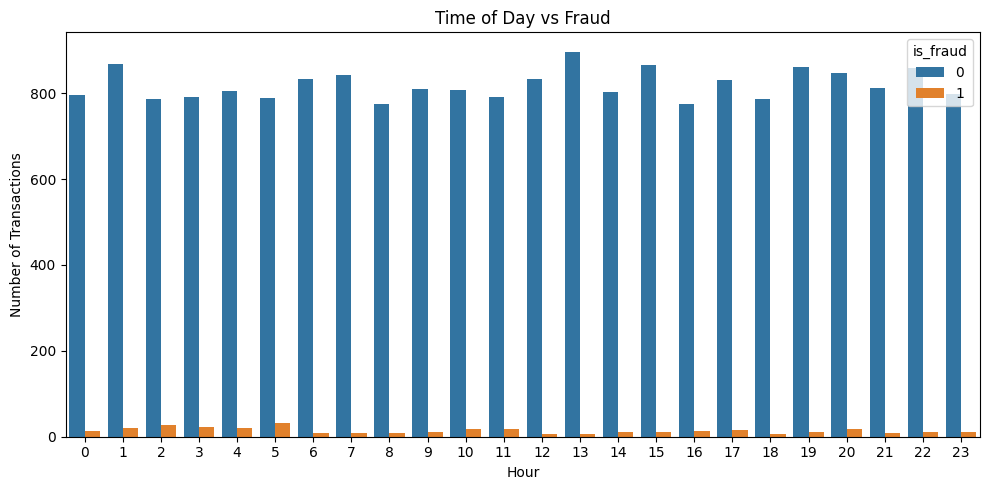

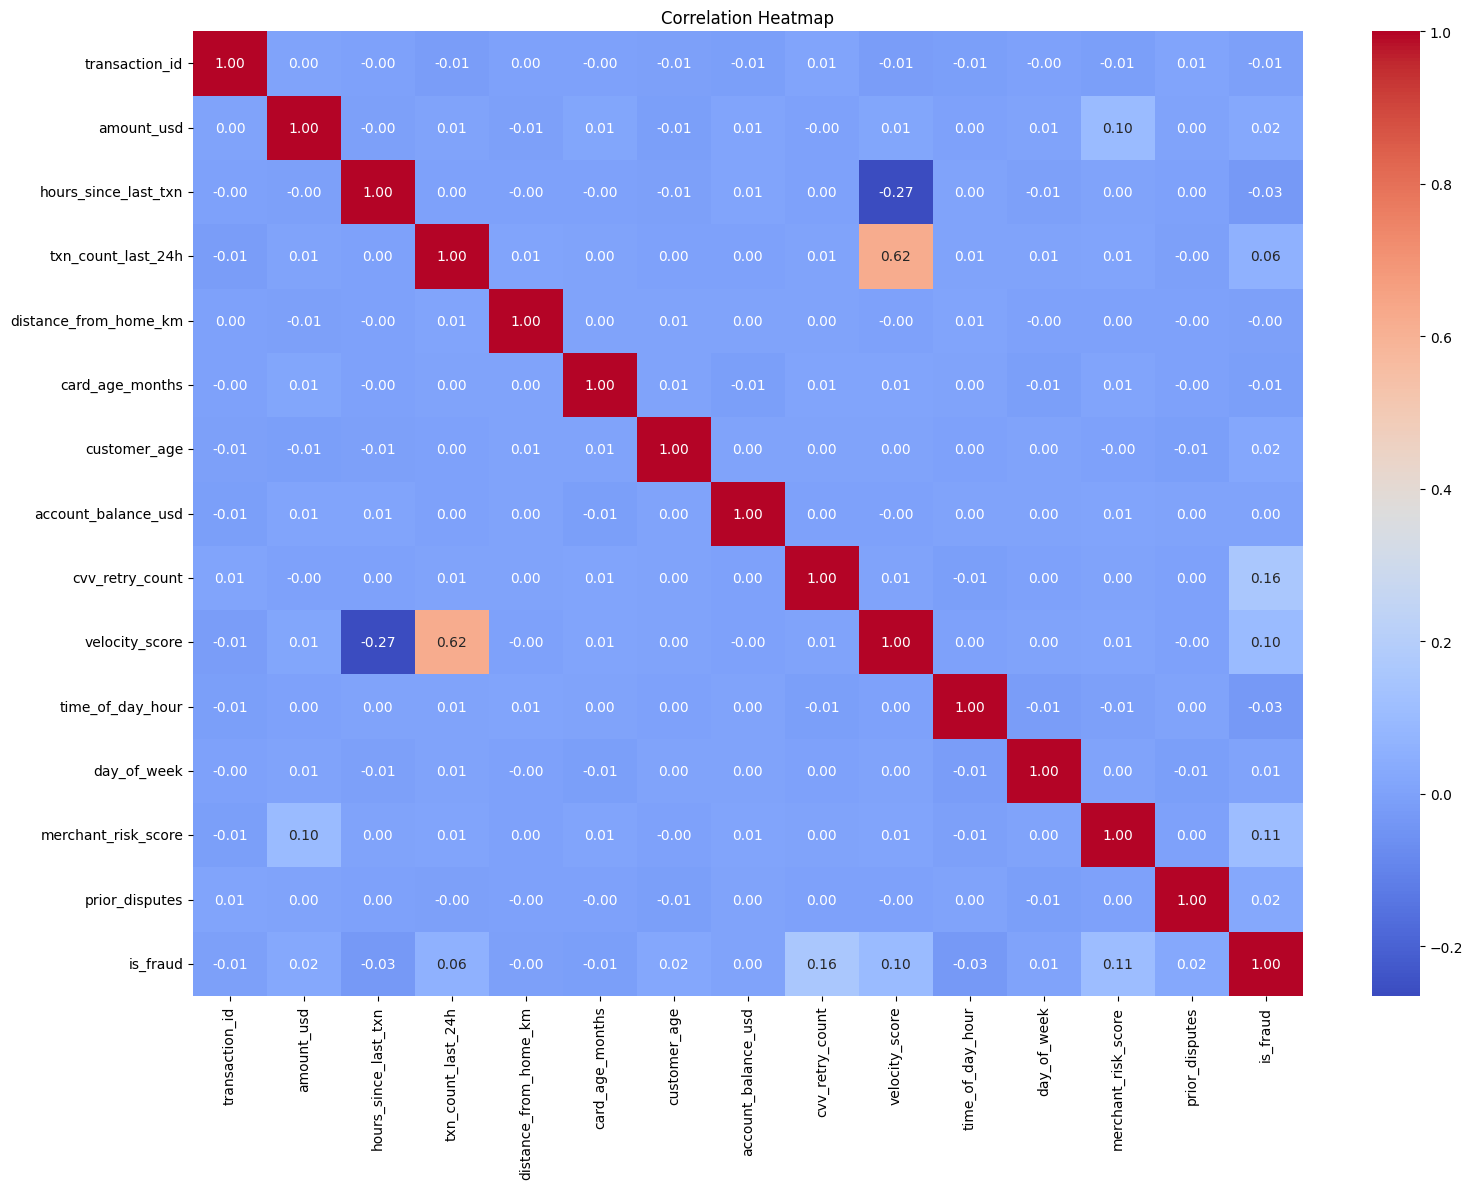


Numerical Columns:
['transaction_id', 'amount_usd', 'hours_since_last_txn', 'txn_count_last_24h', 'distance_from_home_km', 'card_age_months', 'customer_age', 'account_balance_usd', 'cvv_retry_count', 'velocity_score', 'time_of_day_hour', 'day_of_week', 'merchant_risk_score', 'prior_disputes', 'is_fraud']

Categorical Columns:
['merchant_category', 'card_type', 'auth_method', 'channel', 'device_type', 'is_foreign_transaction', 'is_new_merchant', 'used_vpn', 'ip_country_mismatch', 'billing_shipping_mismatch', 'is_ai_generated_scam_attempt']

Outlier Analysis:
transaction_id : 0 outliers
amount_usd : 2061 outliers
hours_since_last_txn : 955 outliers
txn_count_last_24h : 336 outliers
distance_from_home_km : 904 outliers
card_age_months : 177 outliers
customer_age : 0 outliers
account_balance_usd : 1569 outliers
cvv_retry_count : 3342 outliers
velocity_score : 213 outliers
time_of_day_hour : 0 outliers
day_of_week : 0 outliers
merchant_risk_score : 358 outliers
prior_disputes : 4915 outlie

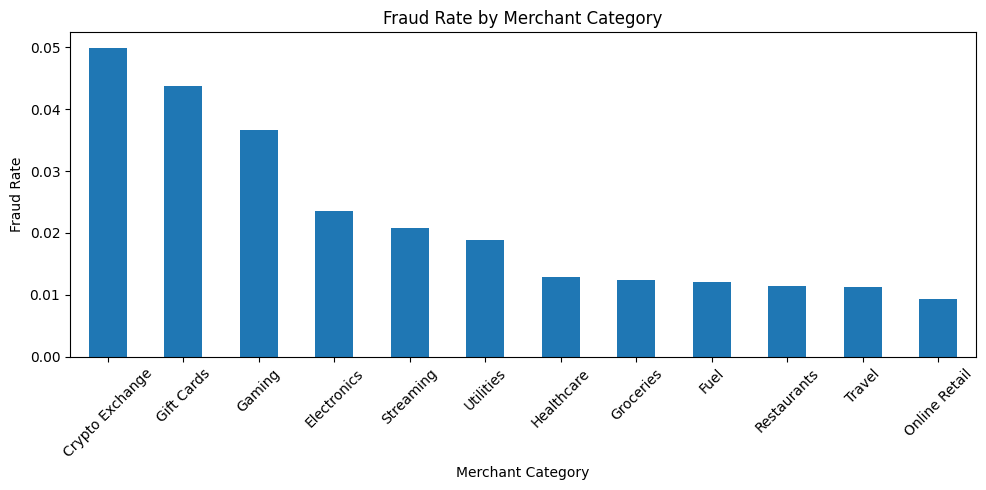


Fraud Rate by Channel:
channel
Online         0.019824
ATM            0.018195
In-App         0.016124
POS            0.015219
Contactless    0.014118
Name: is_fraud, dtype: float64


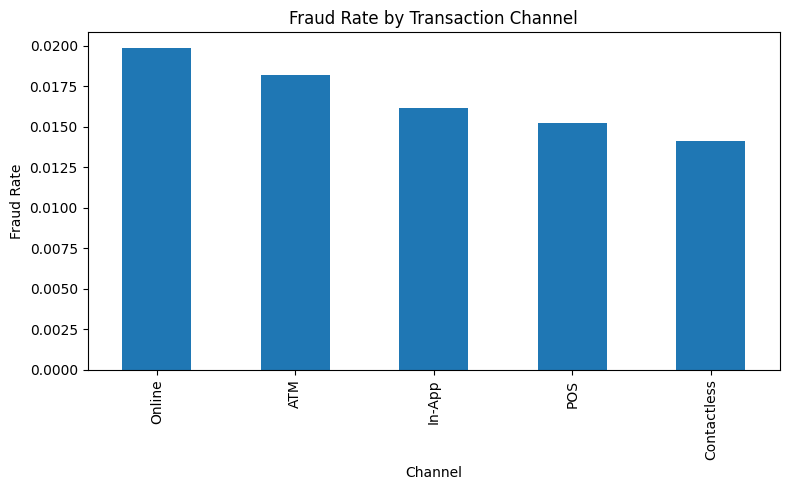


Fraud Rate by Card Type:
card_type
Amex          0.020141
Discover      0.019550
Visa          0.017821
Mastercard    0.015387
RuPay         0.013363
Name: is_fraud, dtype: float64


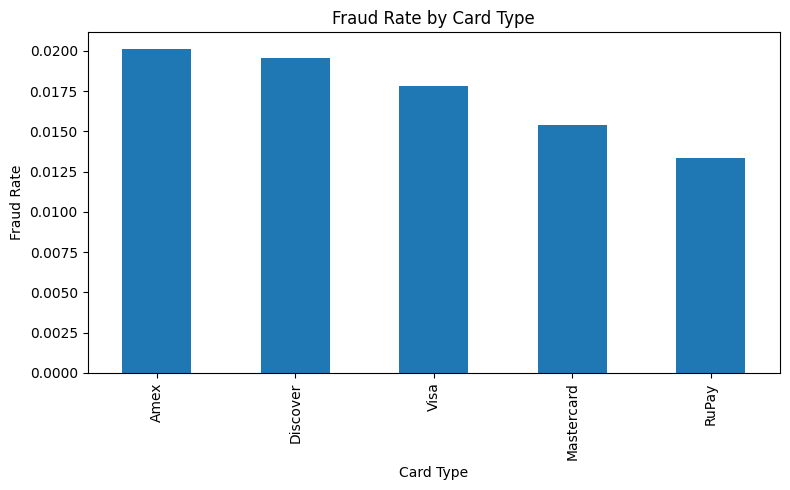


Fraud Rate by Authentication Method:
auth_method
No Authentication    0.044389
OTP                  0.015651
3D Secure            0.015484
PIN                  0.011503
Biometric            0.007759
Name: is_fraud, dtype: float64


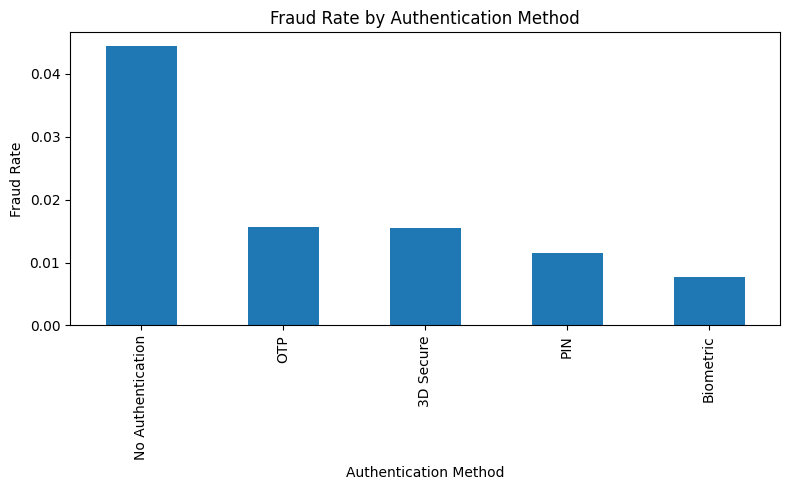


Fraud Rate by Device Type:
device_type
Tablet           0.018949
Android Phone    0.018899
Mac              0.018396
ATM Machine      0.017910
Smart Watch      0.017857
POS Terminal     0.017078
iPhone           0.016511
Windows PC       0.011056
Name: is_fraud, dtype: float64


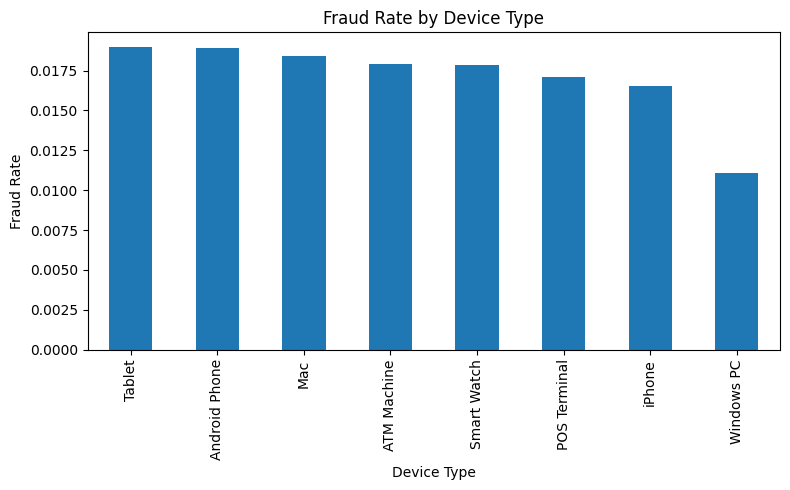


========== FINAL EDA SUMMARY ==========
Rows: 20000
Columns: 26
Missing Values: 0
Duplicate Rows: 0
Fraud Transactions: 339
Fraud Percentage: 1.7 %

EDA Completed Successfully!


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv("credit_card_fraud_2026.csv")

# ============================================================
# BASIC DATASET INFORMATION
# ============================================================

print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()

print("\nStatistical Summary:")
print(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nTotal Missing Values:")
print(df.isnull().sum().sum())

print("\nDuplicate Records:")
print(df.duplicated().sum())

print("\nUnique Values:")
print(df.nunique())

# ============================================================
# FRAUD DISTRIBUTION
# ============================================================

print("\nFraud Distribution:")
print(df["is_fraud"].value_counts())

print("\nFraud Percentage:")
print(df["is_fraud"].value_counts(normalize=True) * 100)

# ============================================================
# 1. FRAUD DISTRIBUTION
# ============================================================

plt.figure(figsize=(6, 4))

sns.countplot(data=df, x="is_fraud")

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Fraud")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

# ============================================================
# 2. TRANSACTION AMOUNT
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="amount_usd",
    bins=50,
    kde=True
)

plt.title("Distribution of Transaction Amount")
plt.xlabel("Transaction Amount (USD)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# ============================================================
# 3. TRANSACTION AMOUNT BY FRAUD
# ============================================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="is_fraud",
    y="amount_usd"
)

plt.title("Transaction Amount by Fraud Status")
plt.xlabel("Fraud")
plt.ylabel("Amount (USD)")
plt.tight_layout()
plt.show()

# ============================================================
# 4. MERCHANT CATEGORY
# ============================================================

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="merchant_category",
    hue="is_fraud"
)

plt.title("Merchant Category vs Fraud")
plt.xticks(rotation=45)
plt.xlabel("Merchant Category")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

# ============================================================
# 5. CARD TYPE
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="card_type",
    hue="is_fraud"
)

plt.title("Card Type vs Fraud")
plt.xlabel("Card Type")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

# ============================================================
# 6. AUTHENTICATION METHOD
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="auth_method",
    hue="is_fraud"
)

plt.title("Authentication Method vs Fraud")
plt.xlabel("Authentication Method")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

# ============================================================
# 7. TRANSACTION CHANNEL
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="channel",
    hue="is_fraud"
)

plt.title("Transaction Channel vs Fraud")
plt.xlabel("Channel")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

# ============================================================
# 8. DEVICE TYPE
# ============================================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="device_type",
    hue="is_fraud"
)

plt.title("Device Type vs Fraud")
plt.xlabel("Device Type")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

# ============================================================
# 9. FOREIGN TRANSACTION
# ============================================================

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="is_foreign_transaction",
    hue="is_fraud"
)

plt.title("Foreign Transaction vs Fraud")
plt.xlabel("Foreign Transaction")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

# ============================================================
# 10. VPN USAGE
# ============================================================

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="used_vpn",
    hue="is_fraud"
)

plt.title("VPN Usage vs Fraud")
plt.xlabel("Used VPN")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

# ============================================================
# 11. IP COUNTRY MISMATCH
# ============================================================

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="ip_country_mismatch",
    hue="is_fraud"
)

# FIXED LINE
plt.title("IP Country Mismatch vs Fraud")

plt.xlabel("IP Country Mismatch")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

# ============================================================
# 12. BILLING SHIPPING MISMATCH
# ============================================================

plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="billing_shipping_mismatch",
    hue="is_fraud"
)

plt.title("Billing Shipping Mismatch vs Fraud")
plt.xlabel("Mismatch")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

# ============================================================
# 13. VELOCITY SCORE
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="velocity_score",
    hue="is_fraud",
    bins=40,
    kde=True
)

plt.title("Velocity Score Distribution")
plt.xlabel("Velocity Score")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# ============================================================
# 14. MERCHANT RISK SCORE
# ============================================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="is_fraud",
    y="merchant_risk_score"
)

plt.title("Merchant Risk Score by Fraud Status")
plt.xlabel("Fraud")
plt.ylabel("Merchant Risk Score")
plt.tight_layout()
plt.show()

# ============================================================
# 15. DISTANCE FROM HOME
# ============================================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="is_fraud",
    y="distance_from_home_km"
)

plt.title("Distance From Home by Fraud Status")
plt.xlabel("Fraud")
plt.ylabel("Distance (km)")
plt.tight_layout()
plt.show()

# ============================================================
# 16. TRANSACTION COUNT
# ============================================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="is_fraud",
    y="txn_count_last_24h"
)

plt.title("Transactions in Last 24 Hours")
plt.xlabel("Fraud")
plt.ylabel("Transaction Count")
plt.tight_layout()
plt.show()

# ============================================================
# 17. CVV RETRY COUNT
# ============================================================

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="is_fraud",
    y="cvv_retry_count"
)

plt.title("CVV Retry Count by Fraud Status")
plt.xlabel("Fraud")
plt.ylabel("CVV Retry Count")
plt.tight_layout()
plt.show()

# ============================================================
# 18. PRIOR DISPUTES
# ============================================================

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="prior_disputes",
    hue="is_fraud"
)

plt.title("Prior Disputes vs Fraud")
plt.xlabel("Prior Disputes")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

# ============================================================
# 19. CUSTOMER AGE
# ============================================================

plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="customer_age",
    hue="is_fraud",
    bins=30,
    kde=True
)

plt.title("Customer Age Distribution")
plt.xlabel("Customer Age")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# ============================================================
# 20. TIME OF DAY
# ============================================================

plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x="time_of_day_hour",
    hue="is_fraud"
)

plt.title("Time of Day vs Fraud")
plt.xlabel("Hour")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

# ============================================================
# 21. CORRELATION HEATMAP
# ============================================================

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(16, 12))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

# ============================================================
# 22. NUMERICAL COLUMNS
# ============================================================

numerical_columns = df.select_dtypes(
    include=["int64", "float64"]
).columns

print("\nNumerical Columns:")
print(numerical_columns.tolist())

# ============================================================
# 23. CATEGORICAL COLUMNS
# ============================================================

categorical_columns = df.select_dtypes(
    include=["object", "bool"]
).columns

print("\nCategorical Columns:")
print(categorical_columns.tolist())

# ============================================================
# 24. OUTLIER DETECTION
# ============================================================

print("\nOutlier Analysis:")

for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

    print(
        column,
        ":",
        len(outliers),
        "outliers"
    )

# ============================================================
# 25. FRAUD RATE BY MERCHANT CATEGORY
# ============================================================

print("\nFraud Rate by Merchant Category:")

fraud_by_merchant = df.groupby(
    "merchant_category"
)["is_fraud"].mean().sort_values(
    ascending=False
)

print(fraud_by_merchant)

plt.figure(figsize=(10, 5))

fraud_by_merchant.plot(kind="bar")

plt.title("Fraud Rate by Merchant Category")
plt.xlabel("Merchant Category")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# 26. FRAUD RATE BY CHANNEL
# ============================================================

print("\nFraud Rate by Channel:")

fraud_by_channel = df.groupby(
    "channel"
)["is_fraud"].mean().sort_values(
    ascending=False
)

print(fraud_by_channel)

plt.figure(figsize=(8, 5))

fraud_by_channel.plot(kind="bar")

plt.title("Fraud Rate by Transaction Channel")
plt.xlabel("Channel")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()

# ============================================================
# 27. FRAUD RATE BY CARD TYPE
# ============================================================

print("\nFraud Rate by Card Type:")

fraud_by_card = df.groupby(
    "card_type"
)["is_fraud"].mean().sort_values(
    ascending=False
)

print(fraud_by_card)

plt.figure(figsize=(8, 5))

fraud_by_card.plot(kind="bar")

plt.title("Fraud Rate by Card Type")
plt.xlabel("Card Type")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()

# ============================================================
# 28. FRAUD RATE BY AUTHENTICATION
# ============================================================

print("\nFraud Rate by Authentication Method:")

fraud_by_auth = df.groupby(
    "auth_method"
)["is_fraud"].mean().sort_values(
    ascending=False
)

print(fraud_by_auth)

plt.figure(figsize=(8, 5))

fraud_by_auth.plot(kind="bar")

plt.title("Fraud Rate by Authentication Method")
plt.xlabel("Authentication Method")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()

# ============================================================
# 29. FRAUD RATE BY DEVICE
# ============================================================

print("\nFraud Rate by Device Type:")

fraud_by_device = df.groupby(
    "device_type"
)["is_fraud"].mean().sort_values(
    ascending=False
)

print(fraud_by_device)

plt.figure(figsize=(8, 5))

fraud_by_device.plot(kind="bar")

plt.title("Fraud Rate by Device Type")
plt.xlabel("Device Type")
plt.ylabel("Fraud Rate")
plt.tight_layout()
plt.show()

# ============================================================
# 30. FINAL DATASET SUMMARY
# ============================================================

print("\n========== FINAL EDA SUMMARY ==========")

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())
print("Fraud Transactions:", df["is_fraud"].sum())

print(
    "Fraud Percentage:",
    round(df["is_fraud"].mean() * 100, 2),
    "%"
)

print("\nEDA Completed Successfully!")